<a href="https://colab.research.google.com/github/razin26/Tugas_DeepLearningCNN_CIFAR10/blob/main/Tugas_Deep_Learning_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU tersedia:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Nama GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU tersedia: True
Nama GPU: Tesla T4


In [3]:
from torchvision import datasets, transforms

# Transformasi untuk data
transform = transforms.ToTensor()

# Download dataset training
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Download dataset testing
test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Jumlah data training:", len(train_dataset))
print("Jumlah data testing :", len(test_dataset))

100%|██████████| 170M/170M [00:11<00:00, 14.6MB/s]


Jumlah data training: 50000
Jumlah data testing : 10000


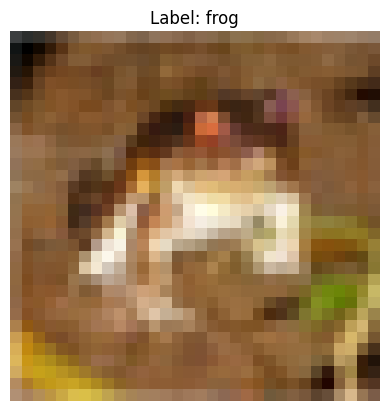

In [4]:
import matplotlib.pyplot as plt

# Nama-nama kelas CIFAR-10
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Ambil gambar pertama
image, label = train_dataset[0]

# Tampilkan gambar
plt.imshow(image.permute(1, 2, 0))
plt.title(f"Label: {classes[label]}")
plt.axis("off")
plt.show()

In [5]:
print("Ukuran gambar :", image.shape)
print("Label angka   :", label)
print("Nama kelas    :", classes[label])

Ukuran gambar : torch.Size([3, 32, 32])
Label angka   : 6
Nama kelas    : frog


In [6]:
from torch.utils.data import random_split

# Menentukan ukuran dataset
train_size = 45000
val_size = 5000

# Membagi dataset training menjadi training dan validation
train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

print("Jumlah data training   :", len(train_dataset))
print("Jumlah data validation :", len(val_dataset))
print("Jumlah data testing    :", len(test_dataset))

Jumlah data training   : 45000
Jumlah data validation : 5000
Jumlah data testing    : 10000


In [7]:
from torchvision import datasets, transforms

# Transformasi untuk data
transform = transforms.ToTensor()

# Dataset training
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Dataset testing
test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Jumlah data training:", len(train_dataset))
print("Jumlah data testing :", len(test_dataset))

Jumlah data training: 50000
Jumlah data testing : 10000


In [8]:
from torch.utils.data import random_split

train_size = 45000
val_size = 5000

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

print("Jumlah data training   :", len(train_dataset))
print("Jumlah data validation :", len(val_dataset))
print("Jumlah data testing    :", len(test_dataset))

Jumlah data training   : 45000
Jumlah data validation : 5000
Jumlah data testing    : 10000


In [9]:
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("DataLoader berhasil dibuat")

DataLoader berhasil dibuat


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device yang digunakan:", device)

Device yang digunakan: cuda


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Block 2
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Block 3
        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        # Pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)


    def forward(self, x):

        # Block 1: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))

        # Block 2: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))

        # Block 3: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten
        x = torch.flatten(x, start_dim=1)

        # Fully Connected
        x = F.relu(self.fc1(x))

        # Output
        x = self.fc2(x)

        return x

In [12]:
model_a = CustomCNN().to(device)

print(model_a)

CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [13]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Jumlah parameter Model A:", count_parameters(model_a))

Jumlah parameter Model A: 620362


In [15]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()

        # Convolution pertama
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        # Convolution kedua
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )
        else:
            self.shortcut = nn.Identity()


    def forward(self, x):

        # Simpan input untuk shortcut
        identity = self.shortcut(x)

        # Jalur utama
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Residual connection
        out = out + identity

        # Aktivasi setelah penjumlahan
        out = F.relu(out)

        return out

In [16]:
class ResidualCNN(nn.Module):
    def __init__(self):
        super(ResidualCNN, self).__init__()

        # Initial convolution
        self.conv = nn.Conv2d(
            3,
            32,
            kernel_size=3,
            padding=1
        )

        self.bn = nn.BatchNorm2d(32)

        # Residual blocks
        self.block1 = ResidualBlock(32, 32)
        self.block2 = ResidualBlock(32, 64)
        self.block3 = ResidualBlock(64, 128)

        # Pooling
        self.pool = nn.MaxPool2d(2, 2)

        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully Connected
        self.fc = nn.Linear(128, 10)


    def forward(self, x):

        # Initial convolution
        x = F.relu(self.bn(self.conv(x)))

        # Residual Block 1
        x = self.block1(x)
        x = self.pool(x)

        # Residual Block 2
        x = self.block2(x)
        x = self.pool(x)

        # Residual Block 3
        x = self.block3(x)

        # Global Average Pooling
        x = self.global_pool(x)

        # Flatten
        x = torch.flatten(x, 1)

        # Output
        x = self.fc(x)

        return x

In [17]:
model_b = ResidualCNN().to(device)

print(model_b)

print(
    "Jumlah parameter Model B:",
    count_parameters(model_b)
)

ResidualCNN(
  (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): ResidualBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Identity()
  )
  (block2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Conv2d(32, 64, kernel_size=(1, 1), stride=(

In [18]:
# Ambil satu batch dari training data
images, labels = next(iter(train_loader))

# Pindahkan ke device
images = images.to(device)
labels = labels.to(device)

# Cek Model A
output_a = model_a(images)

# Cek Model B
output_b = model_b(images)

print("Input shape :", images.shape)
print("Label shape :", labels.shape)
print("Output Model A :", output_a.shape)
print("Output Model B :", output_b.shape)
print("Device input :", images.device)
print("Device Model A :", next(model_a.parameters()).device)
print("Device Model B :", next(model_b.parameters()).device)

Input shape : torch.Size([128, 3, 32, 32])
Label shape : torch.Size([128])
Output Model A : torch.Size([128, 10])
Output Model B : torch.Size([128, 10])
Device input : cuda:0
Device Model A : cuda:0
Device Model B : cuda:0


In [19]:
import torch
import torch.nn as nn

# Hyperparameter
num_epochs = 20
learning_rate = 0.001
batch_size = 128

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer untuk Model A
optimizer_a = torch.optim.Adam(
    model_a.parameters(),
    lr=learning_rate
)

# Optimizer untuk Model B
optimizer_b = torch.optim.Adam(
    model_b.parameters(),
    lr=learning_rate
)

print("Hyperparameter berhasil disiapkan")
print("Epoch        :", num_epochs)
print("Batch size   :", batch_size)
print("Learning rate:", learning_rate)
print("Optimizer    : Adam")

Hyperparameter berhasil disiapkan
Epoch        : 20
Batch size   : 128
Learning rate: 0.001
Optimizer    : Adam


In [20]:
import time

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):

    # Menyimpan hasil setiap epoch
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    # Mulai menghitung waktu
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.time()

    # Training selama beberapa epoch
    for epoch in range(num_epochs):

        # =========================
        # TRAINING
        # =========================
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Reset gradient
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Hitung loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update parameter
            optimizer.step()

            # Simpan loss
            running_loss += loss.item() * images.size(0)

            # Hitung accuracy
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # =========================
        # VALIDATION
        # =========================
        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        # Simpan hasil epoch
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Tampilkan hasil
        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    # Selesaikan pengukuran waktu GPU
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    training_time = time.time() - start_time

    return history, training_time

In [21]:
print("===== TRAINING MODEL A =====")

history_a, time_a = train_model(
    model=model_a,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_a,
    num_epochs=num_epochs,
    device=device
)

print("\nTraining Model A selesai!")
print(f"Total training time Model A: {time_a:.2f} detik")
print(f"Total training time Model A: {time_a/60:.2f} menit")

===== TRAINING MODEL A =====
Epoch [1/20] Train Loss: 1.6020 | Val Loss: 1.4681 | Train Acc: 0.4108 | Val Acc: 0.4752
Epoch [2/20] Train Loss: 1.1995 | Val Loss: 1.0852 | Train Acc: 0.5698 | Val Acc: 0.6200
Epoch [3/20] Train Loss: 1.0128 | Val Loss: 0.9788 | Train Acc: 0.6409 | Val Acc: 0.6622
Epoch [4/20] Train Loss: 0.9010 | Val Loss: 0.9051 | Train Acc: 0.6840 | Val Acc: 0.6808
Epoch [5/20] Train Loss: 0.8037 | Val Loss: 0.8139 | Train Acc: 0.7186 | Val Acc: 0.7136
Epoch [6/20] Train Loss: 0.7192 | Val Loss: 0.8498 | Train Acc: 0.7493 | Val Acc: 0.7072
Epoch [7/20] Train Loss: 0.6542 | Val Loss: 0.7895 | Train Acc: 0.7711 | Val Acc: 0.7238
Epoch [8/20] Train Loss: 0.5878 | Val Loss: 0.7865 | Train Acc: 0.7937 | Val Acc: 0.7320
Epoch [9/20] Train Loss: 0.5335 | Val Loss: 0.7715 | Train Acc: 0.8131 | Val Acc: 0.7376
Epoch [10/20] Train Loss: 0.4784 | Val Loss: 0.8265 | Train Acc: 0.8323 | Val Acc: 0.7316
Epoch [11/20] Train Loss: 0.4139 | Val Loss: 0.8264 | Train Acc: 0.8543 | Val Ac

In [22]:
print("===== TRAINING MODEL B =====")

history_b, time_b = train_model(
    model=model_b,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_b,
    num_epochs=num_epochs,
    device=device
)

print("\nTraining Model B selesai!")
print(f"Total training time Model B: {time_b:.2f} detik")
print(f"Total training time Model B: {time_b/60:.2f} menit")

===== TRAINING MODEL B =====
Epoch [1/20] Train Loss: 1.2438 | Val Loss: 1.3725 | Train Acc: 0.5489 | Val Acc: 0.5314
Epoch [2/20] Train Loss: 0.8440 | Val Loss: 1.4944 | Train Acc: 0.7022 | Val Acc: 0.5020
Epoch [3/20] Train Loss: 0.6762 | Val Loss: 0.9436 | Train Acc: 0.7631 | Val Acc: 0.6820
Epoch [4/20] Train Loss: 0.5701 | Val Loss: 0.8837 | Train Acc: 0.8013 | Val Acc: 0.6978
Epoch [5/20] Train Loss: 0.4923 | Val Loss: 0.7340 | Train Acc: 0.8289 | Val Acc: 0.7424
Epoch [6/20] Train Loss: 0.4277 | Val Loss: 0.6157 | Train Acc: 0.8500 | Val Acc: 0.7856
Epoch [7/20] Train Loss: 0.3759 | Val Loss: 0.6274 | Train Acc: 0.8700 | Val Acc: 0.7940
Epoch [8/20] Train Loss: 0.3232 | Val Loss: 0.8712 | Train Acc: 0.8889 | Val Acc: 0.7404
Epoch [9/20] Train Loss: 0.2825 | Val Loss: 0.6931 | Train Acc: 0.9011 | Val Acc: 0.7844
Epoch [10/20] Train Loss: 0.2458 | Val Loss: 0.8526 | Train Acc: 0.9145 | Val Acc: 0.7376
Epoch [11/20] Train Loss: 0.2101 | Val Loss: 0.7612 | Train Acc: 0.9255 | Val Ac

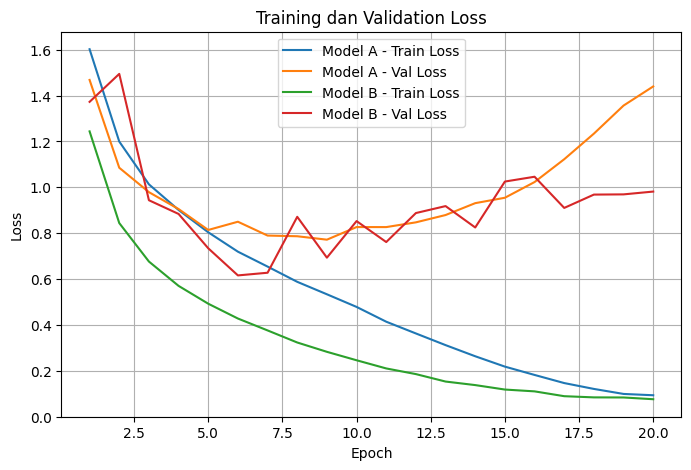

In [23]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

# =========================
# GRAFIK LOSS
# =========================

plt.figure(figsize=(8, 5))

plt.plot(epochs, history_a["train_loss"], label="Model A - Train Loss")
plt.plot(epochs, history_a["val_loss"], label="Model A - Val Loss")
plt.plot(epochs, history_b["train_loss"], label="Model B - Train Loss")
plt.plot(epochs, history_b["val_loss"], label="Model B - Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training dan Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

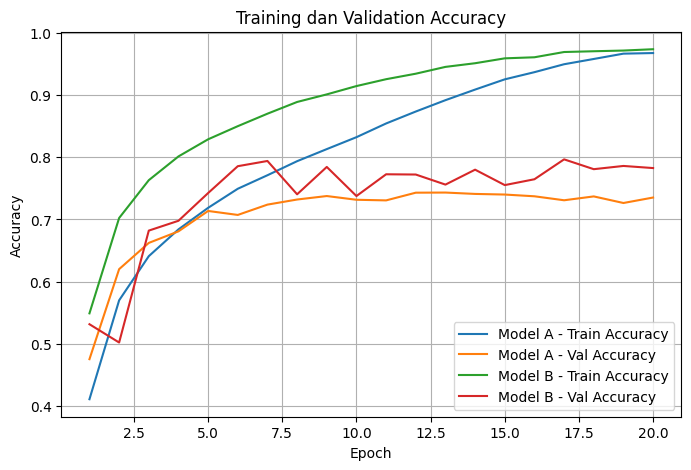

In [24]:
# =========================
# GRAFIK ACCURACY
# =========================

plt.figure(figsize=(8, 5))

plt.plot(epochs, history_a["train_acc"], label="Model A - Train Accuracy")
plt.plot(epochs, history_a["val_acc"], label="Model A - Val Accuracy")
plt.plot(epochs, history_b["train_acc"], label="Model B - Train Accuracy")
plt.plot(epochs, history_b["val_acc"], label="Model B - Val Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training dan Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
def evaluate_test(model, test_loader, device):

    model.eval()

    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Simpan untuk confusion matrix
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total

    return accuracy, all_labels, all_predictions

In [26]:
test_acc_a, y_true_a, y_pred_a = evaluate_test(
    model_a,
    test_loader,
    device
)

print(f"Test Accuracy Model A: {test_acc_a:.4f}")
print(f"Test Accuracy Model A: {test_acc_a * 100:.2f}%")

Test Accuracy Model A: 0.7269
Test Accuracy Model A: 72.69%


In [27]:
test_acc_b, y_true_b, y_pred_b = evaluate_test(
    model_b,
    test_loader,
    device
)

print(f"Test Accuracy Model B: {test_acc_b:.4f}")
print(f"Test Accuracy Model B: {test_acc_b * 100:.2f}%")

Test Accuracy Model B: 0.7871
Test Accuracy Model B: 78.71%


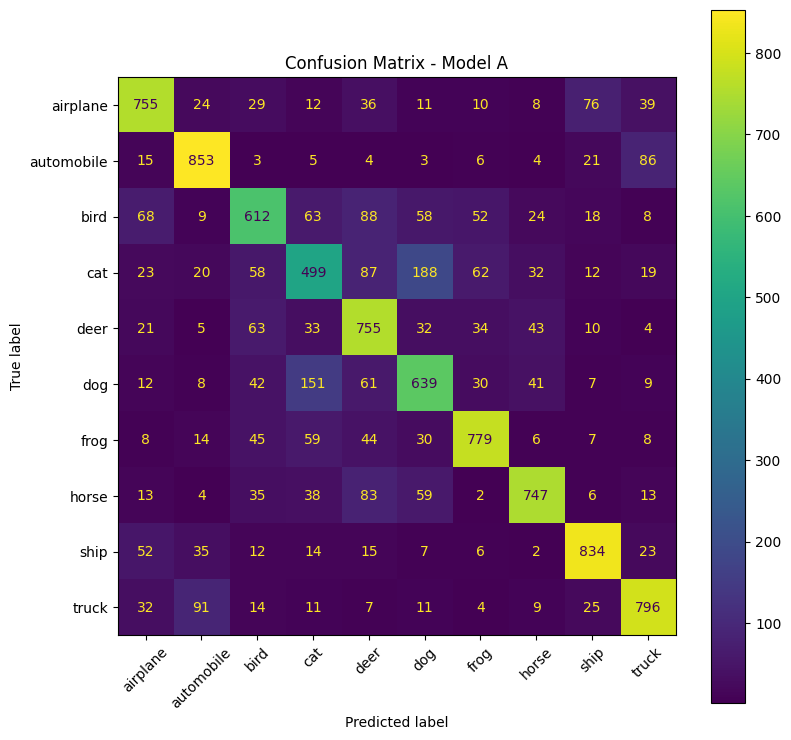

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

# Confusion matrix Model A
cm_a = confusion_matrix(y_true_a, y_pred_a)

disp_a = ConfusionMatrixDisplay(
    confusion_matrix=cm_a,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 9))

disp_a.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Model A")
plt.show()

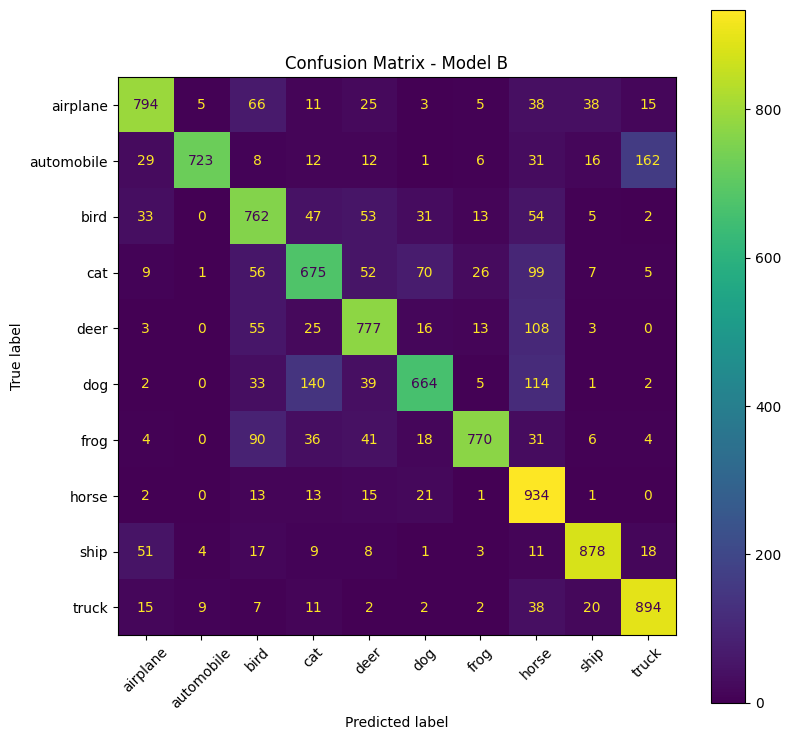

In [29]:
# Confusion matrix Model B
cm_b = confusion_matrix(y_true_b, y_pred_b)

disp_b = ConfusionMatrixDisplay(
    confusion_matrix=cm_b,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 9))

disp_b.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Model B")
plt.show()